In [16]:
!pip install segmentation-models-pytorch albumentations
!pip install segmentation-models-pytorch

In [32]:
# 1. Install and import the Earth Engine API (run in Colab or your terminal)
# !pip install earthengine-api geemap

import ee
import geemap

# 1. First, authenticate your account.
# This will pop up a window asking for permission to link to your Google account.
ee.Authenticate()

# 2. Initialize Earth Engine using your specific Project ID.
# IMPORTANT: Replace 'YOUR-PROJECT-ID' with the actual ID you copied in Step 1.
project_id = 'flood-detection-491109'

try:
    ee.Initialize(project=project_id)
    print("Earth Engine Initialized successfully!")
except Exception as e:
    print(f"Initialization failed: {e}")

print("Earth Engine Initialized!")

# 3. Define your Area of Interest (AOI)
longitude = 68.12 # Indus River, Sindh Province, Pakistan
latitude = 26.60

# We are increasing the buffer to 5000m to capture a massive 10km x 10km area!
aoi = ee.Geometry.Point([longitude, latitude]).buffer(5000).bounds()

# THE NORMAL STATE: Spring Dry Season
start_date = '2022-08-25'
end_date = '2022-09-15'

# 4. Pull the Sentinel-1 SAR Data
sentinel_1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(aoi)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .select(['VV', 'VH']))

first_image = sentinel_1.first()
print("Successfully retrieved Sentinel-1 image metadata:", first_image.getInfo()['id'])

# Optional: If you want to visualize this right in Colab using geemap
# Map = geemap.Map()
# Map.centerObject(aoi, 11)
# Map.addLayer(first_image, {'min': -25, 'max': 5}, 'SAR VV')
# Map

Earth Engine Initialized successfully!
Earth Engine Initialized!
Successfully retrieved Sentinel-1 image metadata: COPERNICUS/S1_GRD/S1A_IW_GRDH_1SDV_20220827T133609_20220827T133634_044739_055782_48B2


In [6]:
import os
import torch
import rasterio
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader # >>> THE FIX: Imported Dataset here! <<<

# >>> NEW UPGRADE 1: The Albumentations Pipeline <<<
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3), # Warps the flood boundaries!
    ToTensorV2(), # Converts back to PyTorch Tensors automatically
])

class SARFloodDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        super().__init__()
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_names = [f for f in os.listdir(image_dir) if f.endswith('.tif')]
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_name = img_name.replace('_S1Hand', '_LabelHand')
        mask_path = os.path.join(self.mask_dir, mask_name)

        # 1. Load Image
        with rasterio.open(img_path) as src:
            image = src.read() # Shape: (2, Height, Width)
            image = np.nan_to_num(image)
            image = np.clip(image, -30.0, 0.0)
            image = (image + 30.0) / 30.0

            # >>> THE FIX: CREATE A 3RD CHANNEL <<<
            # We average Band 1 and Band 2 to create a 3rd "Pseudo" band.
            band3 = (image[0:1, :, :] + image[1:2, :, :]) / 2.0
            image = np.concatenate([image, band3], axis=0)

            # Albumentations needs (Height, Width, Channels)
            image = np.transpose(image, (1, 2, 0))

        # 2. Load Mask
        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = np.where(mask > 0, 1.0, 0.0)

        # 3. Apply the Heavy Artillery Augmentations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            mask = mask.unsqueeze(0).float()
            image = image.float()
        else:
            image = torch.from_numpy(np.transpose(image, (2, 0, 1))).float()
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return image, mask

In [7]:
import torch
import torch.nn as nn

# 1. Define the basic building block: Two convolutions in a row
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# 2. Build the U-Net Architecture
class SAR_UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1): # 2 inputs (VV, VH), 1 output (Water Mask)
        super(SAR_UNet, self).__init__()

        # ENCODER (Shrinking the image, finding features)
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # BOTTLENECK (The bottom of the "U")
        self.bottleneck = DoubleConv(128, 256)

        # DECODER (Expanding the image, placing features back on the map)
        self.upTranspose1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up1 = DoubleConv(256, 128) # 256 because of the skip connection!

        self.upTranspose2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up2 = DoubleConv(128, 64)

        # FINAL OUTPUT (Mapping to a single probability channel)
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Go down the U (Encoder)
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        # Cross the bottom (Bottleneck)
        b = self.bottleneck(p2)

        # Go up the U (Decoder)
        # Note: torch.cat is the "Skip Connection" bringing detailed spatial info over from the encoder
        u1 = self.upTranspose1(b)
        u1 = self.up1(torch.cat([u1, d2], dim=1))

        u2 = self.upTranspose2(u1)
        u2 = self.up2(torch.cat([u2, d1], dim=1))

        # Final prediction map
        output = torch.sigmoid(self.out_conv(u2)) # Sigmoid squashes output between 0 and 1 (probability)
        return output

# Let's test if the model builds successfully
model = SAR_UNet()
dummy_sar_image = torch.randn(1, 2, 256, 256) # 1 batch, 2 channels, 256x256 image size
prediction = model(dummy_sar_image)

print("Model built successfully!")
print(f"Input shape: {dummy_sar_image.shape}")
print(f"Output shape: {prediction.shape} (Ready to be compared against a ground truth mask!)")

Model built successfully!
Input shape: torch.Size([1, 2, 256, 256])
Output shape: torch.Size([1, 1, 256, 256]) (Ready to be compared against a ground truth mask!)


In [8]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import torch
import segmentation_models_pytorch as smp # >>> NEW IMPORT FOR RESNET <<<

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# >>> NEW UPGRADE 1: The BCEDiceLoss Function <<<
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(BCEDiceLoss, self).__init__()
        # BCEWithLogitsLoss is infinitely more stable than BCELoss!
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, preds, targets):
        # 1. BCEWithLogits handles the raw predictions safely
        bce_loss = self.bce(preds, targets)

        # 2. For Dice, we manually apply the sigmoid to get our 0-to-1 probabilities
        preds_probs = torch.sigmoid(preds)

        preds_flat = preds_probs.view(-1)
        targets_flat = targets.view(-1)

        intersection = (preds_flat * targets_flat).sum()
        dice_score = (2. * intersection + self.smooth) / (preds_flat.sum() + targets_flat.sum() + self.smooth)
        dice_loss = 1 - dice_score

        return bce_loss + dice_loss
# ------------------------------------------------


# --- ENGINE UPGRADE: Smarter Training ---
learning_rate = 1e-4
epochs = 100
batch_size = 8

# >>> BULLETPROOF UPGRADE 2: Remove activation="sigmoid" <<<
# The model will output raw numbers (logits), and the new loss function will handle them safely!
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

criterion = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)


def calculate_iou(preds, labels, threshold=0.5):
    preds = (preds > threshold).float()
    intersection = (preds * labels).sum()
    union = preds.sum() + labels.sum() - intersection
    if union == 0:
        return torch.tensor(1.0)
    return intersection / union


def train_model(image_dir, mask_dir):
    # >>> NEW UPGRADE 3: Pass the 'train_transform' into your dataset <<<
    # This connects the Albumentations pipeline (flips, rotations, grid warping) to the training loop
    dataset = SARFloodDataset(image_dir=image_dir, mask_dir=mask_dir, transform=train_transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    best_iou = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_iou = 0.0

        for images, masks in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            predictions = model(images)
            loss = criterion(predictions, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_iou += calculate_iou(predictions, masks).item()

        avg_loss = running_loss / len(dataloader)
        avg_iou = (running_iou / len(dataloader)) * 100

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Accuracy (IoU): {avg_iou:.2f}%")

        # Tell the scheduler what our score was so it can adjust
        scheduler.step(avg_iou)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr}")

        # Model Checkpointing
        if avg_iou > best_iou:
            print(f"🌟 IoU improved from {best_iou:.2f}% to {avg_iou:.2f}%. Saving new best model!")
            best_iou = avg_iou
            torch.save(model.state_dict(), 'sar_flood_resnet34_best.pth') # Renamed slightly so you don't overwrite your vanilla UNet!

    print(f"\nTraining Complete! The highest IoU achieved was: {best_iou:.2f}%")
    print("The smartest version of your AI is safely saved as 'sar_flood_resnet34_best.pth'")

# Run the training
# train_model('path_to_images', 'path_to_masks')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [9]:
import os
import numpy as np
import rasterio
from rasterio.transform import from_origin

# 1. Create the folders that our PyTorch Dataset is looking for
os.makedirs('train_images', exist_ok=True)
os.makedirs('train_masks', exist_ok=True)

def generate_dummy_data(num_images=10, size=256):
    print(f"Generating {num_images} synthetic SAR images and masks...")

    # Arbitrary spatial metadata (Rasterio needs this to save a valid geotiff)
    transform = from_origin(92.0, 26.0, 10, 10)

    for i in range(num_images):
        # 2. Create Fake SAR Image (2 channels: VV, VH)
        # Real SAR data is usually in decibels (-30 to 0). We generate random noise in that range.
        fake_sar = np.random.normal(loc=-15, scale=5, size=(2, size, size)).astype(np.float32)
        fake_sar = np.clip(fake_sar, -30.0, 0.0)

        # 3. Create Fake Flood Mask (1 channel: 0=Land, 1=Water)
        # Creating random water patches
        fake_mask = (np.random.rand(1, size, size) > 0.8).astype(np.uint8)

        # 4. Save them as .tif files
        img_filename = f'train_images/sample_{i}.tif'
        mask_filename = f'train_masks/sample_{i}.tif'

        # Write the SAR Image
        with rasterio.open(
            img_filename, 'w', driver='GTiff',
            height=size, width=size, count=2, dtype=str(fake_sar.dtype),
            crs='+proj=latlong', transform=transform
        ) as dst:
            dst.write(fake_sar)

        # Write the Ground Truth Mask
        with rasterio.open(
            mask_filename, 'w', driver='GTiff',
            height=size, width=size, count=1, dtype=str(fake_mask.dtype),
            crs='+proj=latlong', transform=transform
        ) as dst:
            dst.write(fake_mask)

    print("Done! The folders 'train_images' and 'train_masks' are now populated.")

generate_dummy_data()

Generating 10 synthetic SAR images and masks...
Done! The folders 'train_images' and 'train_masks' are now populated.


In [10]:
# Create folders for the real data
!mkdir -p real_data/S1
!mkdir -p real_data/Labels

print("Downloading Sentinel-1 Radar Images...")
# The -m flag makes it download in parallel (super fast)
!gsutil -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand real_data/S1

print("Downloading Ground Truth Masks...")
!gsutil -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand real_data/Labels

print("Download Complete!")

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.

both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".

Building synchronization state...
Starting synchronization...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_314919_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_103757_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_23014_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_36051

In [ ]:
train_model('real_data/S1', 'real_data/Labels')

Epoch 1/100: 100%|██████████| 56/56 [00:34<00:00,  1.60it/s]


Epoch [1/100] | Loss: 1.2738 | Accuracy (IoU): 33.01%
Current Learning Rate: 0.0001
🌟 IoU improved from 0.00% to 33.01%. Saving new best model!


Epoch 2/100: 100%|██████████| 56/56 [00:33<00:00,  1.69it/s]


Epoch [2/100] | Loss: 0.9949 | Accuracy (IoU): 44.68%
Current Learning Rate: 0.0001
🌟 IoU improved from 33.01% to 44.68%. Saving new best model!


Epoch 3/100: 100%|██████████| 56/56 [00:33<00:00,  1.68it/s]


...

Epoch [98/100] | Loss: 0.3562 | Accuracy (IoU): 64.48%
Current Learning Rate: 5e-05


Epoch 99/100: 100%|██████████| 56/56 [00:34<00:00,  1.62it/s]


Epoch [99/100] | Loss: 0.3460 | Accuracy (IoU): 65.65%
Current Learning Rate: 5e-05
🌟 IoU improved from 65.63% to 65.65%. Saving new best model!


Epoch 100/100: 100%|██████████| 56/56 [00:34<00:00,  1.61it/s]


Epoch [100/100] | Loss: 0.3393 | Accuracy (IoU): 66.24%
Current Learning Rate: 5e-05
🌟 IoU improved from 65.65% to 66.24%. Saving new best model!

Training Complete! The highest IoU achieved was: 66.24%
The smartest version of your AI is safely saved as 'sar_flood_resnet34_best.pth'


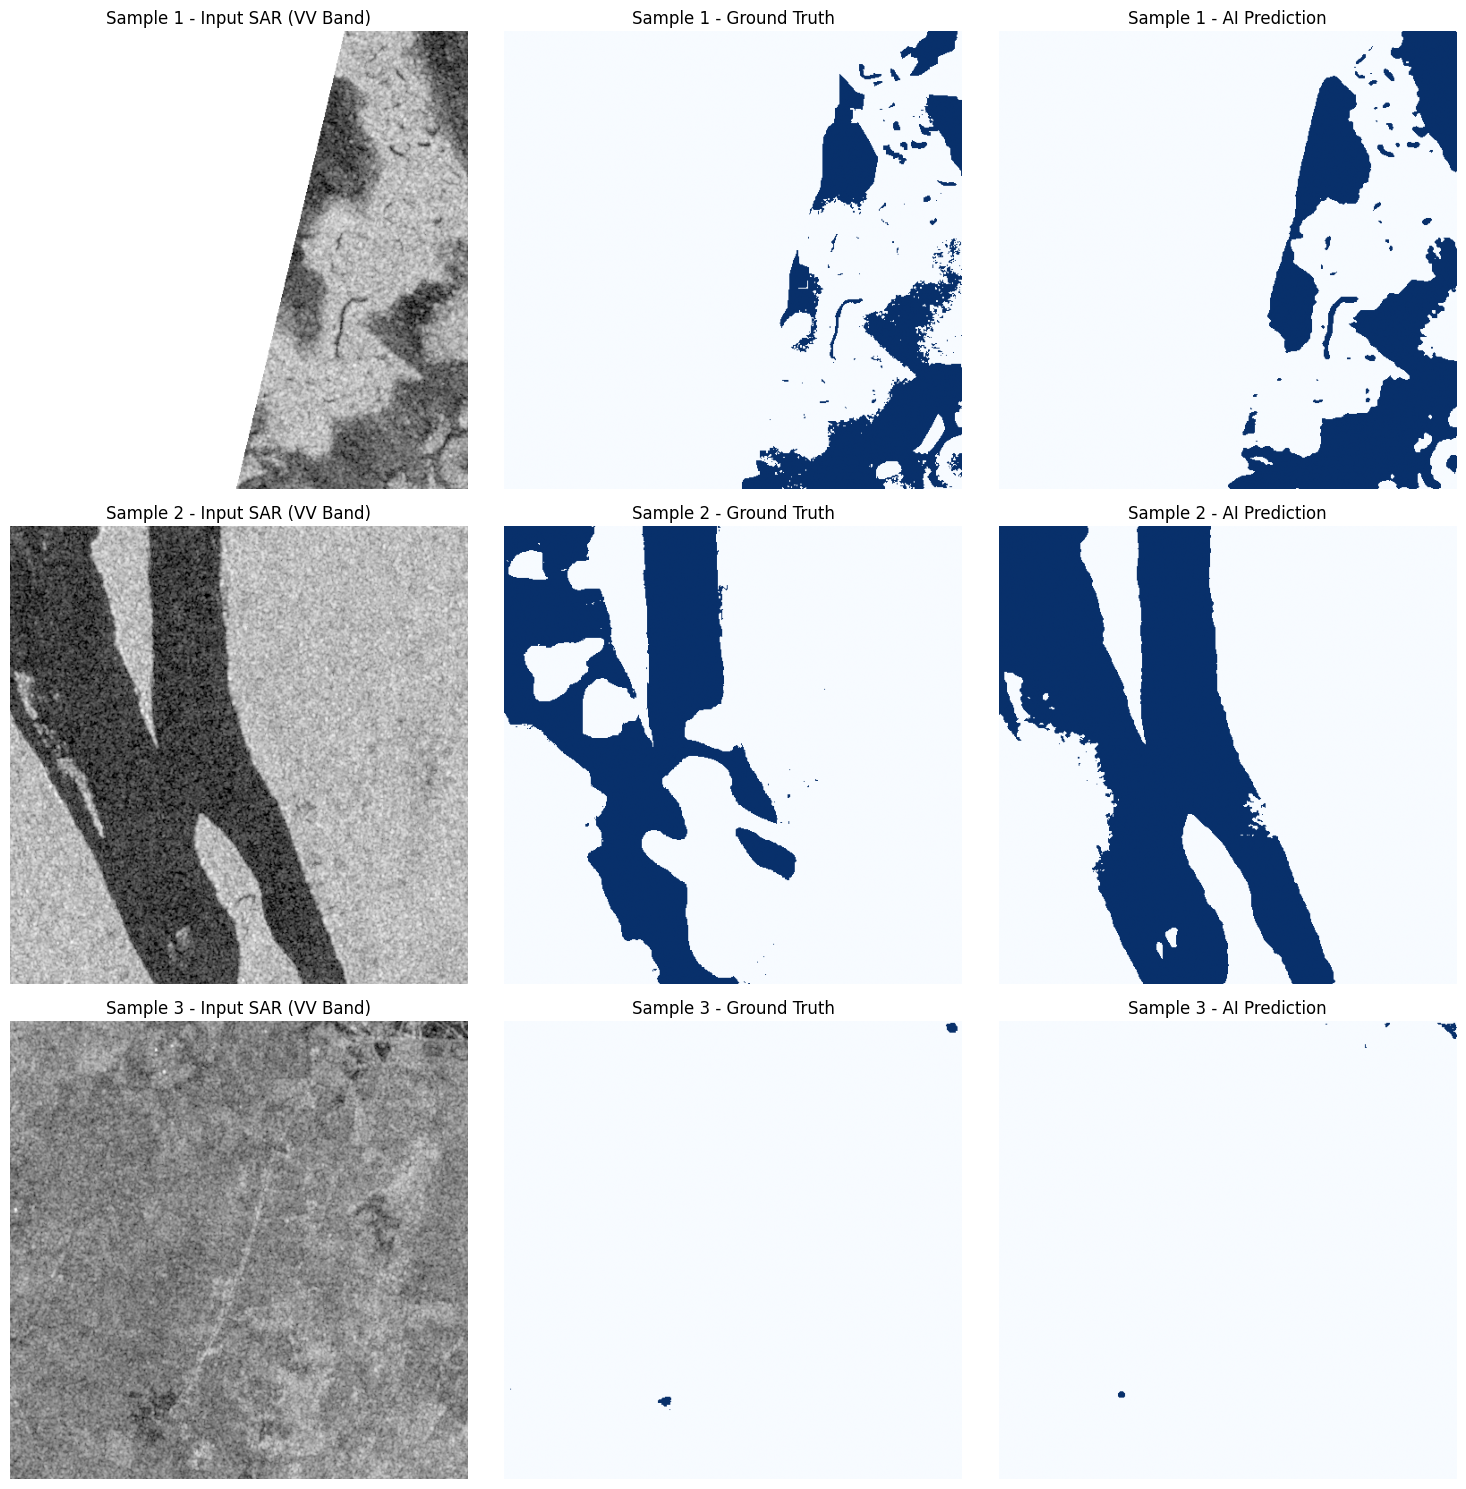

In [14]:
import matplotlib.pyplot as plt
import random
import torch
import numpy as np
import segmentation_models_pytorch as smp

def visualize_multiple_predictions(model_path, image_dir, mask_dir, num_samples=3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # >>> FIX 1: Use the correct ResNet-34 blueprint! <<<
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None, # We don't need to download imagenet weights, we have our own!
        in_channels=3,
        classes=1
    ).to(device)

    # >>> FIX 2: Safely load the model regardless of GPU availability <<<
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # We do NOT pass train_transform here because we don't want to warp the images we are looking at!
    dataset = SARFloodDataset(image_dir=image_dir, mask_dir=mask_dir)

    # Create a grid of plots: num_samples rows, 3 columns
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    for i in range(num_samples):
        # Grab a random image
        random_idx = random.randint(0, len(dataset) - 1)
        image, true_mask = dataset[random_idx]

        # Make a Prediction
        image_batch = image.unsqueeze(0).to(device)
        with torch.no_grad():
            raw_prediction = model(image_batch)
            # >>> FIX 3: Apply Sigmoid because our model outputs raw numbers now <<<
            probs = torch.sigmoid(raw_prediction)

        pred_mask = probs.squeeze().cpu().numpy()
        binary_pred_mask = (pred_mask > 0.5).astype(np.uint8)

        # Plot the Results in the correct row
        # image[0] is still the VV Band, even with our 3rd pseudo-channel added!
        sar_display = image[0].numpy()

        # Input Image
        axes[i, 0].imshow(sar_display, cmap='gray')
        axes[i, 0].set_title(f'Sample {i+1} - Input SAR (VV Band)')
        axes[i, 0].axis('off')

        # Ground Truth
        axes[i, 1].imshow(true_mask.squeeze().numpy(), cmap='Blues')
        axes[i, 1].set_title(f'Sample {i+1} - Ground Truth')
        axes[i, 1].axis('off')

        # Prediction
        axes[i, 2].imshow(binary_pred_mask, cmap='Blues')
        axes[i, 2].set_title(f'Sample {i+1} - AI Prediction')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer pointing to the PRO model!
visualize_multiple_predictions('sar_flood_resnet34_best.pth', 'real_data/S1', 'real_data/Labels', num_samples=3)

Generating URL ...
Please wait ...


Data downloaded to /content/gee_temp_patch.tif


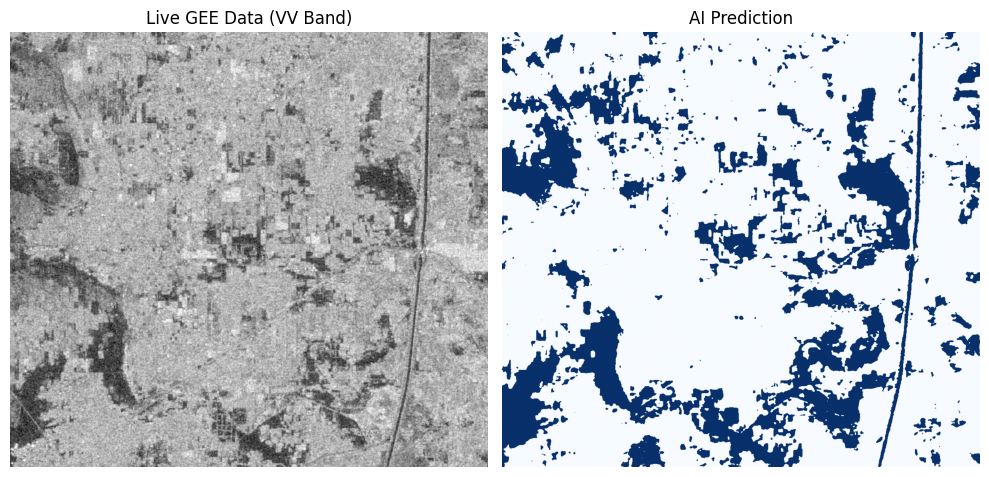

In [33]:
import geemap
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
import os
import segmentation_models_pytorch as smp

def predict_on_earth_engine(model_path, ee_image, aoi):
    print("Downloading Earth Engine patch for inference...")

    temp_file = 'gee_temp_patch.tif'
    if os.path.exists(temp_file):
        os.remove(temp_file)

    # We force the download to use standard GPS Degrees (EPSG:4326)
    geemap.ee_export_image(
        ee_image, filename=temp_file, scale=10, region=aoi, crs='EPSG:4326', file_per_band=False
    )

    with rasterio.open(temp_file) as src:
        image = src.read()
        image = np.nan_to_num(image)

        # Handle edge case where GEE only returns 1 band
        if image.shape[0] == 1:
            image = np.vstack((image, image))

        # 1. Calculate the actual image size dynamically (Fixes the downward shift)
        height, width = image.shape[1], image.shape[2]
        new_h = (height // 32) * 32
        new_w = (width // 32) * 32
        image = image[:, :new_h, :new_w]

        # 2. CREATE A 3RD CHANNEL (Fixes the ResNet crash)
        band3 = (image[0:1, :, :] + image[1:2, :, :]) / 2.0
        image = np.concatenate([image, band3], axis=0)

        # 3. Calculate exact GPS bounds for the new dynamic shape
        min_lon, max_lat = src.transform * (0, 0)
        max_lon, min_lat = src.transform * (new_w, new_h)
        crop_bounds = [[min_lat, min_lon], [max_lat, max_lon]]

        image = np.clip(image, -30.0, 0.0)
        image = (image + 30.0) / 30.0

    image_tensor = torch.from_numpy(image).float().unsqueeze(0)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Use the ResNet-34 blueprint with 3 in_channels
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=1
    ).to(device)

    # >>> THE FIX: Safely load the weights to the CPU if the GPU is missing! <<<
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    with torch.no_grad():
        raw_prediction = model(image_tensor.to(device))
        probs = torch.sigmoid(raw_prediction)

    binary_pred_mask = (probs.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image[0], cmap='gray') # Displaying band 0 (VV)
    axes[0].set_title('Live GEE Data (VV Band)')
    axes[0].axis('off')
    axes[1].imshow(binary_pred_mask, cmap='Blues')
    axes[1].set_title('AI Prediction')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    return binary_pred_mask, crop_bounds

# Run the live prediction pointing to your smartest model!
binary_pred_mask, exact_bounds = predict_on_earth_engine('sar_flood_resnet34_best.pth', first_image, aoi)

Generating Interactive Map...



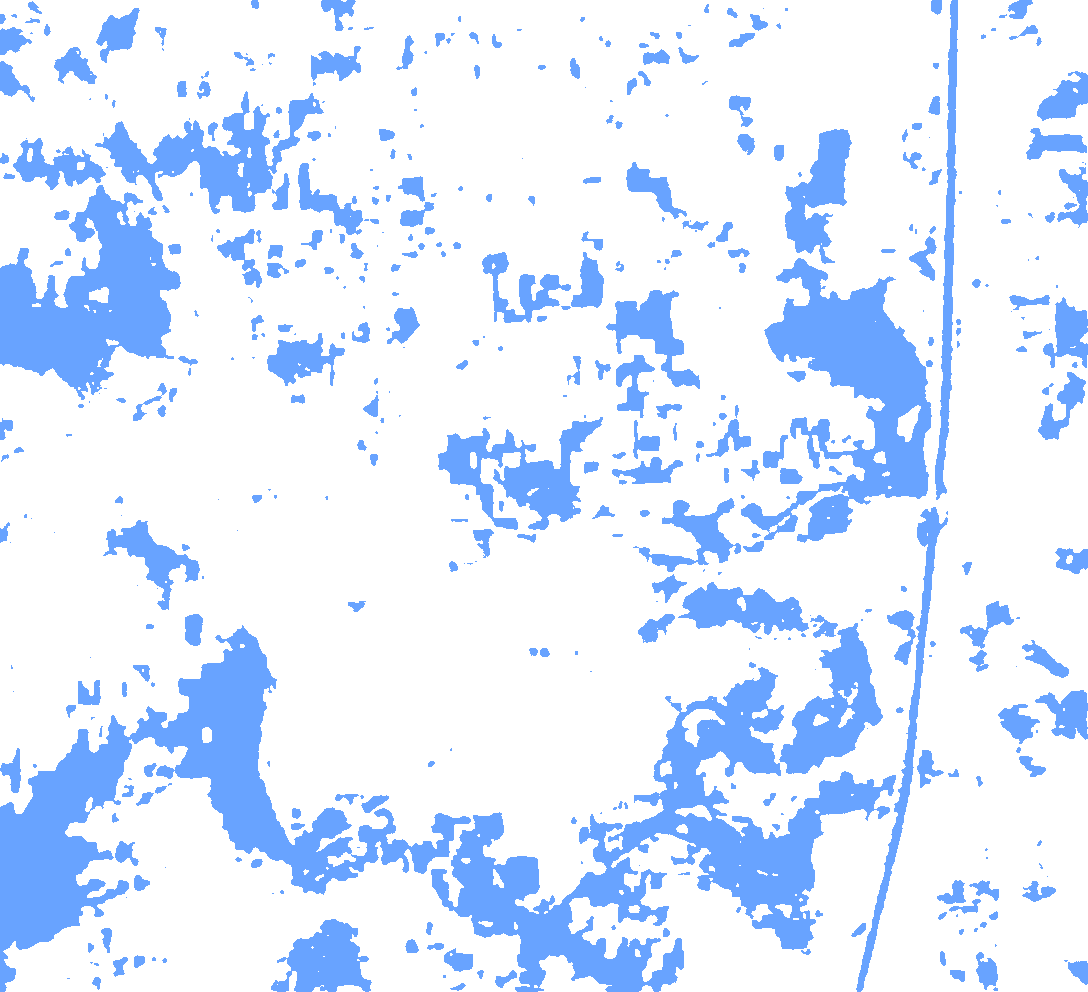

In [34]:
import folium
import numpy as np

def create_interactive_map(binary_mask, bounds): # We now accept the exact bounds!
    print("Generating Interactive Map...")

    # Center the map perfectly in the middle of our crop
    center_lat = (bounds[0][0] + bounds[1][0]) / 2
    center_lon = (bounds[0][1] + bounds[1][1]) / 2

    m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

    folium.TileLayer(
        tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr='Esri',
        name='Satellite Base',
        overlay=False
    ).add_to(m)

    h, w = binary_mask.shape
    rgba_image = np.zeros((h, w, 4), dtype=np.uint8)
    rgba_image[binary_mask == 1] = [0, 100, 255, 150]

    folium.raster_layers.ImageOverlay(
        image=rgba_image,
        bounds=bounds, # Apply the exact bounds here
        name='AI Flood Prediction',
        interactive=True,
        cross_origin=False,
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m

# Run it using the exact bounds we generated in Cell 9
interactive_map = create_interactive_map(binary_pred_mask, exact_bounds)
interactive_map